In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb



In [2]:
wandb.login()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: mitalee-garg (mitalee-garg-tu-darmstadt). Use `wandb login --relogin` to force relogin


True

Trained with some changes #200 epochs

In [3]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_4/metrics.csv"
metrics_df = pd.read_csv(file_path)

Plot the AUC-PR curve


In [4]:
# Print available columns to check the correct column name
print("Available columns:", metrics_df.columns)

Available columns: Index(['train_precision_step', 'epoch', 'step', 'train_loss_step',
       'train_accuracy_step', 'lr-AdamW', 'val_best_f1/user_6',
       'val_loss/user_7', 'val_loss/user_4', 'val_recall',
       ...
       'train_loss/user_1', 'train_loss/user_8', 'train_best_f1/user_10',
       'train_loss/user_2', 'train_precision/user_4', 'train_loss/user_9',
       'train_best_f1/user_7', 'train_precision/user_1',
       'train_best_f1/user_9', 'train_loss/user_4'],
      dtype='object', length=125)


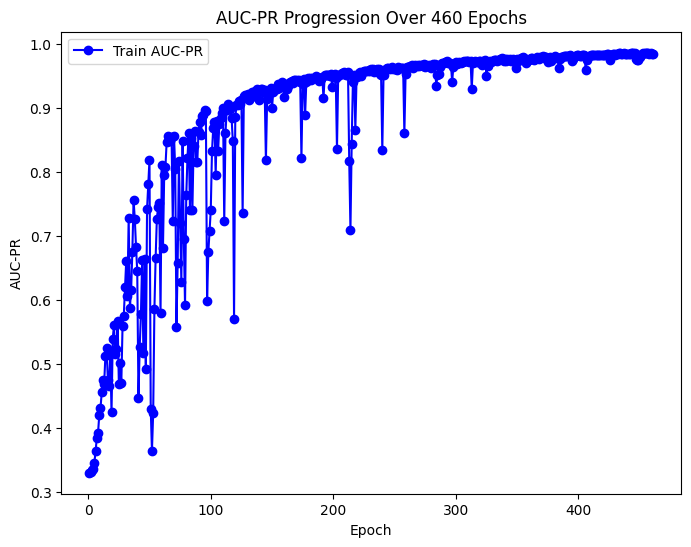

In [5]:
wandb.init(project="Parcel Delivery", name="graph_logging_run_460epochs")

# Extract 'train_auc_pr' column, dropping any NaN values
train_auc_pr = metrics_df['train_auc_pr'].dropna().values
epochs = range(1, len(train_auc_pr) + 1)

# Plot AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_auc_pr, marker='o', linestyle='-', color='b', label='Train AUC-PR')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 460 Epochs')
plt.legend()
wandb.log({" AUC-PR Progression Over 460 Epochs": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

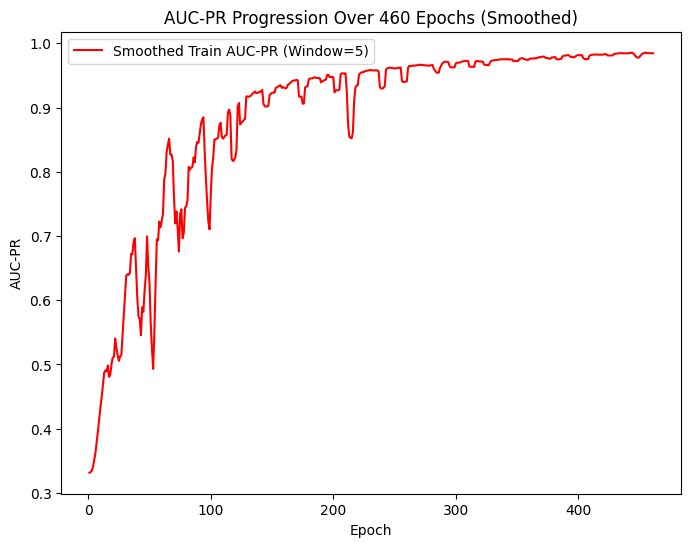

In [12]:
wandb.init(project="Parcel Delivery", name="graph_logging_run_460epochs")
# Extract 'train_auc_pr' column, dropping any NaN values
train_auc_pr = metrics_df['train_auc_pr'].dropna().values
epochs = range(1, len(train_auc_pr) + 1)

# Smoothing function (simple moving average)
def smooth(values, window_size):
    smoothed_values = pd.Series(values).rolling(window=window_size, min_periods=1, center=True).mean()
    return smoothed_values

# Apply smoothing with a window size of 5 (adjust as needed)
smoothed_auc_pr = smooth(train_auc_pr, window_size=5)

# Plot original and smoothed AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, smoothed_auc_pr, color='r', label='Smoothed Train AUC-PR (Window=5)')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 460 Epochs (Smoothed)')
plt.legend()
wandb.log({" AUC-PR Progression Over 460 Epochs (Smoothed)": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

# Extract the epochs and other metrics columns

In [7]:
# Check if both 'epoch' and 'train_loss/user_1' columns exist
if 'epoch' in metrics_df.columns and 'train_loss/user_1' in metrics_df.columns:
    # Filter the DataFrame for 'epoch' and 'train_loss/user_1'
    filtered_df_user_1 = metrics_df[['epoch', 'train_loss_epoch', 'train_best_f1', 'train_precision_epoch', 'train_accuracy_epoch', 'train_recall', 'train_optimal_threshold']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_loss_user_1 = filtered_df_user_1.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch' and 'train_loss':\n", distinct_epochs_and_loss_user_1)
else:
    print("Either 'epoch' or 'train_loss' column is not available in the DataFrame.")


Distinct values of 'epoch' and 'train_loss':
        epoch  train_loss_epoch  train_best_f1  train_precision_epoch  \
211      0.0          1.184177       0.483849               0.336992   
423      1.0          1.179687       0.489325               0.344653   
635      2.0          1.174113       0.486313               0.337852   
847      3.0          1.171900       0.489870               0.344581   
1059     4.0          1.167942       0.496632               0.355003   
...      ...               ...            ...                    ...   
96883  456.0          0.163984       0.938073               0.925660   
97095  457.0          0.174199       0.934552               0.917592   
97307  458.0          0.169075       0.929599               0.914573   
97519  459.0          0.164213       0.940120               0.922758   
97731  460.0          0.168386       0.929063               0.914900   

       train_accuracy_epoch  train_recall  train_optimal_threshold  
211                0

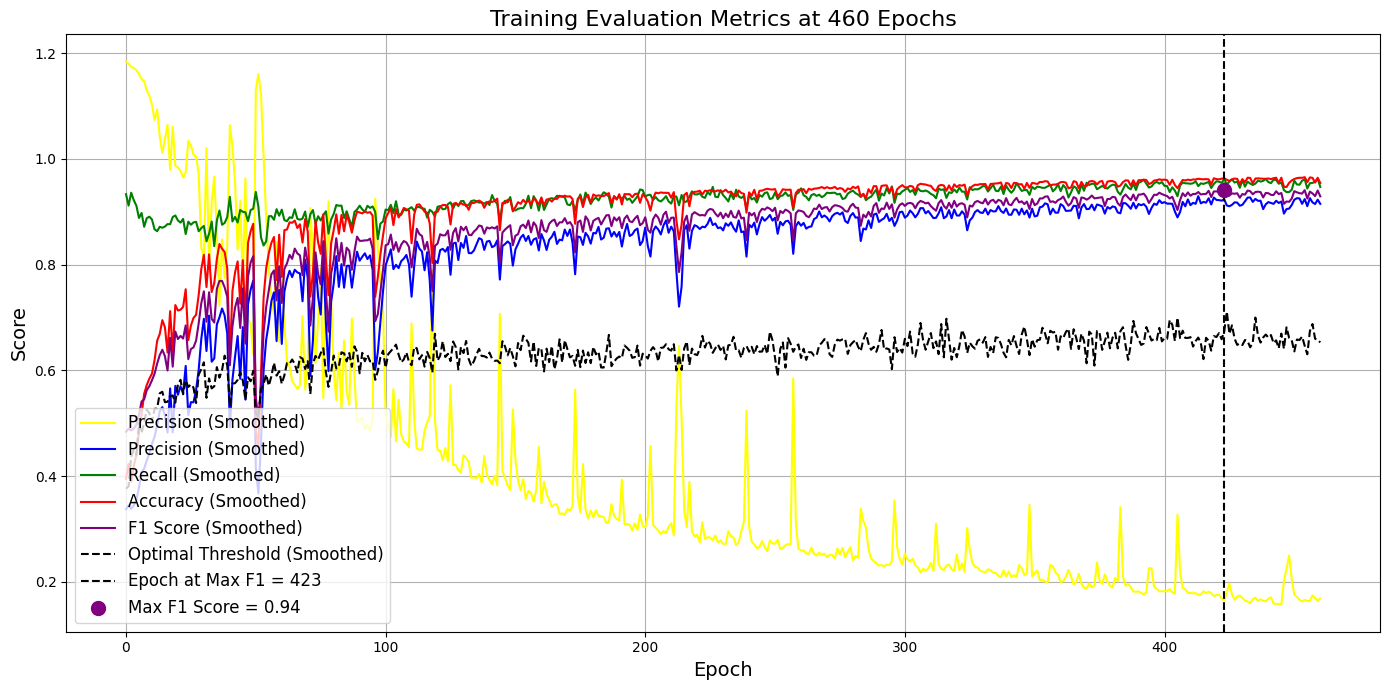

Optimal Threshold: 0.67


In [8]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_4/metrics.csv"
metrics_df = pd.read_csv(file_path)

# Group the data by epoch and calculate mean for each metric
grouped_metrics = metrics_df.groupby('epoch').mean()

# Extract epochs and metrics for plotting
epochs = grouped_metrics.index
loss_smooth = grouped_metrics['train_loss_epoch']
precision_smooth = grouped_metrics['train_precision_epoch']
recall_smooth = grouped_metrics['train_recall']
accuracy_smooth = grouped_metrics['train_accuracy_epoch']
f1_smooth = grouped_metrics['train_best_f1']
threshold_smooth = grouped_metrics['train_optimal_threshold']

# Find the maximum F1 score and corresponding threshold
max_f1_index = f1_smooth.idxmax()
optimal_threshold = threshold_smooth[max_f1_index]
max_f1_score = f1_smooth[max_f1_index]

# Plot all metrics together
plt.figure(figsize=(14, 7))
plt.plot(epochs, loss_smooth, label='Precision (Smoothed)', color='yellow')
plt.plot(epochs, precision_smooth, label='Precision (Smoothed)', color='blue')
plt.plot(epochs, recall_smooth, label='Recall (Smoothed)', color='green')
plt.plot(epochs, accuracy_smooth, label='Accuracy (Smoothed)', color='red')
plt.plot(epochs, f1_smooth, label='F1 Score (Smoothed)', color='purple')
plt.plot(epochs, threshold_smooth, label='Optimal Threshold (Smoothed)', color='black', linestyle='--')

# Highlight the optimal threshold and max F1 score
plt.axvline(x=max_f1_index, color='black', linestyle='--', label=f'Epoch at Max F1 = {max_f1_index:.0f}')
plt.scatter(max_f1_index, max_f1_score, color='purple', s=100, label=f'Max F1 Score = {max_f1_score:.2f}', zorder=5)

# Customize plot labels and grid
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Training Evaluation Metrics at 460 Epochs', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

# Print the optimal threshold for reference
print(f"Optimal Threshold: {optimal_threshold:.2f}")


# Validation plots


Validation auc_pr

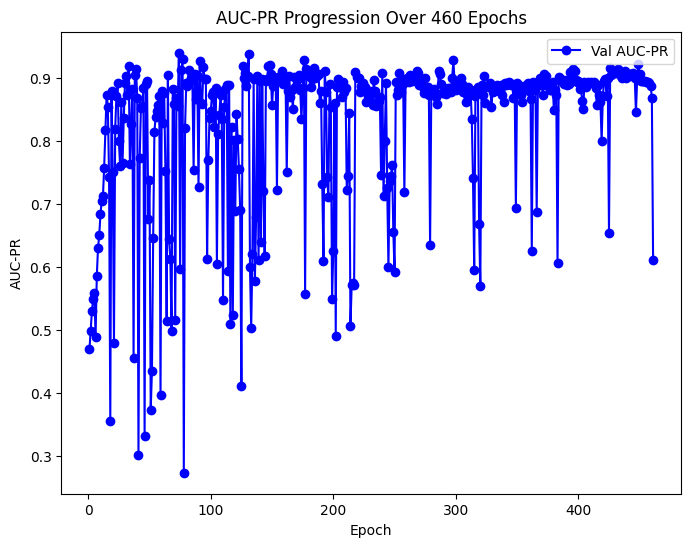

In [9]:
wandb.init(project="Parcel Delivery", name="graph_logging_run_460epochs")

# Extract 'val_auc_pr' column, dropping any NaN values
val_auc_pr = metrics_df['val_auc_pr'].dropna().values
epochs = range(1, len(val_auc_pr) + 1)

# Plot AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, val_auc_pr, marker='o', linestyle='-', color='b', label='Val AUC-PR')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 460 Epochs')
plt.legend()
wandb.log({" AUC-PR Progression Over 460 Epochs": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

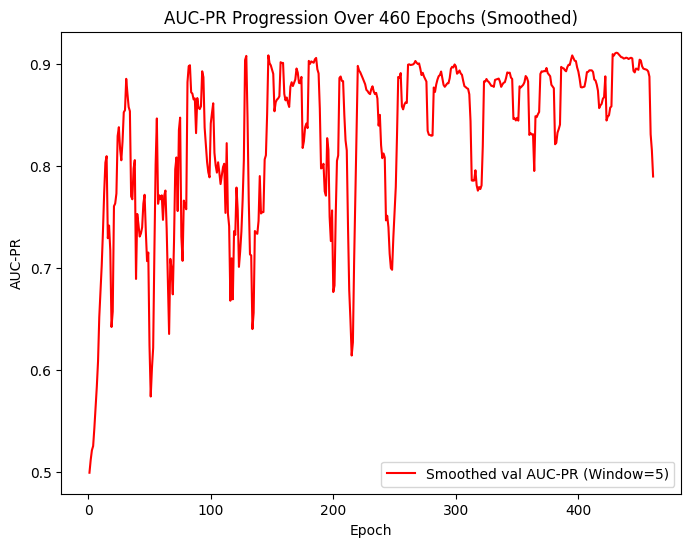

In [10]:
wandb.init(project="Parcel Delivery", name="graph_logging_run_460epochs")
# Extract 'val_auc_pr' column, dropping any NaN values
val_auc_pr = metrics_df['val_auc_pr'].dropna().values
epochs = range(1, len(val_auc_pr) + 1)

# Smoothing function (simple moving average)
def smooth(values, window_size):
    smoothed_values = pd.Series(values).rolling(window=window_size, min_periods=1, center=True).mean()
    return smoothed_values

# Apply smoothing with a window size of 5 (adjust as needed)
smoothed_auc_pr = smooth(val_auc_pr, window_size=5)

# Plot original and smoothed AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, smoothed_auc_pr, color='r', label='Smoothed val AUC-PR (Window=5)')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 460 Epochs (Smoothed)')
plt.legend()
wandb.log({" AUC-PR Progression Over 460 Epochs (Smoothed)": wandb.Image(plt)})

# Show the plot
plt.show()
wandb.finish()

Plotting epochs vs metrics and finding optimal threshold


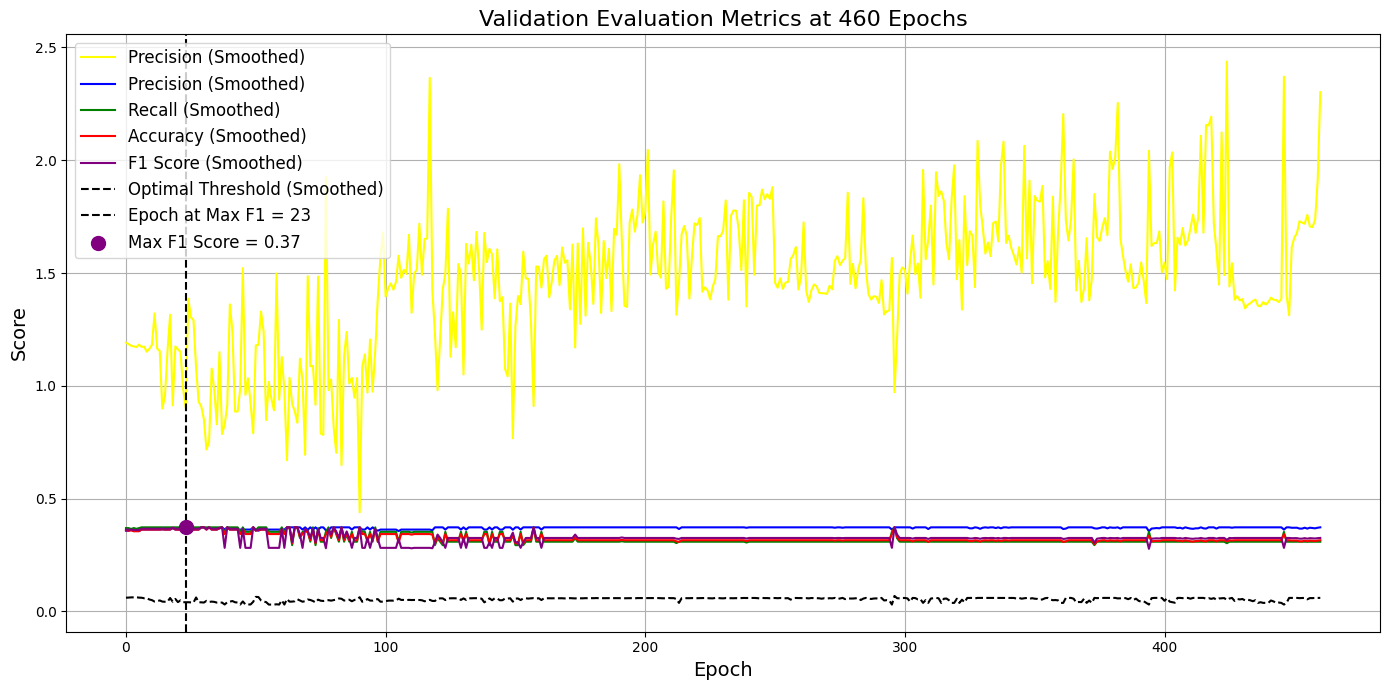

Optimal Threshold: 0.04


In [11]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_4/metrics.csv"
metrics_df = pd.read_csv(file_path)

# Group the data by epoch and calculate mean for each metric
grouped_metrics = metrics_df.groupby('epoch').mean()

# Extract epochs and metrics for plotting
epochs = grouped_metrics.index
loss_smooth = grouped_metrics['val_loss']
precision_smooth = grouped_metrics['val_precision']
recall_smooth = grouped_metrics['val_recall']
accuracy_smooth = grouped_metrics['val_accuracy']
f1_smooth = grouped_metrics['val_best_f1']
threshold_smooth = grouped_metrics['val_optimal_threshold']

# Find the maximum F1 score and corresponding threshold
max_f1_index = f1_smooth.idxmax()
optimal_threshold = threshold_smooth[max_f1_index]
max_f1_score = f1_smooth[max_f1_index]

# Plot all metrics together
plt.figure(figsize=(14, 7))
plt.plot(epochs, loss_smooth, label='Precision (Smoothed)', color='yellow')
plt.plot(epochs, precision_smooth, label='Precision (Smoothed)', color='blue')
plt.plot(epochs, recall_smooth, label='Recall (Smoothed)', color='green')
plt.plot(epochs, accuracy_smooth, label='Accuracy (Smoothed)', color='red')
plt.plot(epochs, f1_smooth, label='F1 Score (Smoothed)', color='purple')
plt.plot(epochs, threshold_smooth, label='Optimal Threshold (Smoothed)', color='black', linestyle='--')

# Highlight the optimal threshold and max F1 score
plt.axvline(x=max_f1_index, color='black', linestyle='--', label=f'Epoch at Max F1 = {max_f1_index:.0f}')
plt.scatter(max_f1_index, max_f1_score, color='purple', s=100, label=f'Max F1 Score = {max_f1_score:.2f}', zorder=5)

# Customize plot labels and grid
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Validation Evaluation Metrics at 460 Epochs', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

# Print the optimal threshold for reference
print(f"Optimal Threshold: {optimal_threshold:.2f}")
